In [1]:
import os, subprocess, torch
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from IPython.display import display

from codes.sprint.models import *
from codes.sprint.data import BrainMultimodalDataset, create_diagonal_split
from codes.sprint.training import (
    evaluate_models, evaluate_per_protein_models, load_histories,
    plot_comparison, plot_metrics, train_engine,
)
from codes.sprint.utils import set_seed, get_device


In [2]:
os.getcwd()

'/media/yuzhi/My PSSD/spatialProtein/spatialProtein/Github'

In [3]:
def select_least_used_cuda_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")

    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=index,memory.used,memory.total",
                "--format=csv,noheader,nounits",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        gpu_rows = []
        for line in result.stdout.strip().splitlines():
            index, used, total = [item.strip() for item in line.split(",")]
            gpu_rows.append(
                {
                    "index": int(index),
                    "used_mb": int(used),
                    "total_mb": int(total),
                    "used_ratio": int(used) / max(int(total), 1),
                }
            )
        if gpu_rows:
            best = min(gpu_rows, key=lambda row: (row["used_mb"], row["used_ratio"], row["index"]))
            print("Detected CUDA devices:")
            for row in gpu_rows:
                marker = " <-- selected" if row["index"] == best["index"] else ""
                print(
                    f"  cuda:{row['index']} used={row['used_mb']} MB / {row['total_mb']} MB "
                    f"({row['used_ratio']:.1%}){marker}"
                )
            torch.cuda.set_device(best["index"])
            return torch.device(f"cuda:{best['index']}")
    except Exception as exc:
        print(f"nvidia-smi GPU selection failed: {exc}. Falling back to PyTorch default CUDA device.")

    return get_device()



In [4]:
device = select_least_used_cuda_device()
set_seed(42)
print(f"Using device: {device}")

Detected CUDA devices:
  cuda:0 used=642 MB / 11264 MB (5.7%) <-- selected
Using device: cuda:0


Loading data from: datas/brain/Brain_Multimodal_Final_256px.h5ad ...
Raw Images Shape: (5756, 256, 256)
Using ALL Genes (No HVG filter).
RNA Input Shape: (5756, 18085)
Data Ready (Diagonal Split)!
Train: 3283 spots (Upper Triangle)
Test:  2473 spots (Lower Triangle)


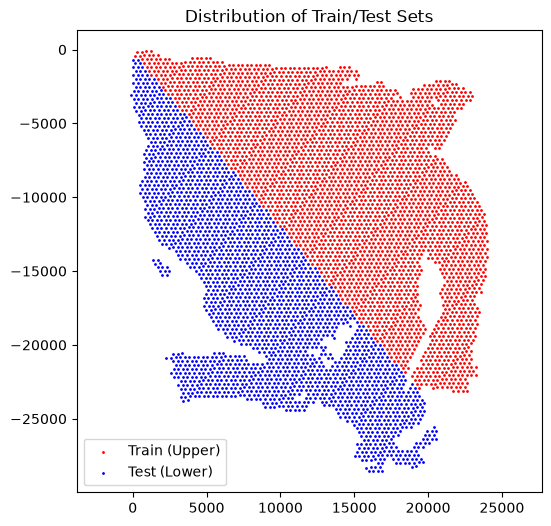

Target Protein Count: 31
Gene Count: 18085


In [5]:
dataset_path = "datas/brain/Brain_Multimodal_Final_256px.h5ad"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"File not found: {dataset_path}")

full_dataset = BrainMultimodalDataset(dataset_path)
NUM_PROTEINS = len(full_dataset.protein_names)
NUM_GENES = full_dataset.rna_data.shape[1]
model_kwargs = {"num_genes": NUM_GENES}

train_dataset, val_dataset, train_loader, val_loader = create_diagonal_split(
    full_dataset,
    batch_size=128,
    num_workers=0,
    drop_last=True,
    plot=True,
)

print(f"Target Protein Count: {NUM_PROTEINS}")
print(f"Gene Count: {NUM_GENES}")


In [7]:
model_name = 'A220260728'
MODEL_REGISTRY = {
    model_name: Model_SchemeA2,
}

MAIN_MODELS = [
    (Model_SchemeA2, model_name),
]

ABLATION_MODELS = [
    (Model_RNA_Only )
]

In [8]:
models_to_train = MAIN_MODELS
all_histories = {}

In [ ]:
print(f"Scheduled to train {len(models_to_train)} main models...")
for i, (model_cls, name) in enumerate(models_to_train):
    print(f"[{i + 1}/{len(models_to_train)}] Processing Model: {name}")
    history = train_engine(
        model_cls,
        name,
        train_loader,
        val_loader,
        num_proteins=NUM_PROTEINS,
        device=device,
        epochs=30,
        model_kwargs=model_kwargs,
    )
    all_histories[name] = history

print("All main models trained successfully!")

In [10]:
ablation_models = ABLATION_MODELS

In [ ]:
print(f"Starting Ablation Studies on {len(ablation_models)} models...")
for i, (model_cls, name) in enumerate(ablation_models):
    print(f"[{i + 1}/{len(ablation_models)}] Ablation Test: {name}")
    history = train_engine(
        model_cls,
        name,
        train_loader,
        val_loader,
        num_proteins=NUM_PROTEINS,
        device=device,
        epochs=30,
        model_kwargs=model_kwargs,
    )
    all_histories[name] = history

print("All ablation models trained successfully!")
